In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

In [2]:
def plot_training_curve(file_path, title, metric_name = "Accuracy", layers=None):
    df = pd.read_csv(file_path, sep="\t")
    plt.figure(figsize=(24, 6))
    for index, row in df.iterrows():
        if layers is not None and index not in layers:
            continue
        plt.plot([int(x) for x in df.columns], row, label=f'Layer {index}')
        
    plt.xlabel('Step')
    plt.ylabel(metric_name)
    plt.legend()
    plt.title(title)
    
    plt.show()

In [24]:
def plot_pair_training_curve(target_path, dependent_path, title, metric_name = "Accuracy", layers=None, x_max=None):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t")
    plt.figure(figsize=(24, 6))
    # make the x axis logarithmic
    #plt.yscale('log')
    for index, row in df_target.iterrows():
        if layers is not None and index not in layers:
            continue
        x_target, y_target = [int(x) for x in df_target.columns], row

        # normalize the y_target values by the first value of y_target
        #y_target = [y - y_target.iloc[0] for y in y_target]
        if x_max is not None:
            x_target = x_target[:x_max]
            y_target = y_target[:x_max]
        spline = UnivariateSpline(x_target, y_target, s=0.1)
        y_smooth = spline(x_target)
        plt.plot(x_target, y_target, label=f'Layer {index} To')
        #plt.plot(x_target, y_smooth, label=f'Layer {index+1} Target')

        x_dependent, y_dependent = [int(x) for x in df_dep.columns], df_dep.iloc[index]
        if x_max is not None:
            x_dependent = x_dependent[:x_max]
            y_dependent = y_dependent[:x_max]
        #y_dependent = [y - y_dependent.iloc[0] for y in y_dependent]
        spline = UnivariateSpline(x_dependent, y_dependent)
        y_smooth = spline(x_dependent)
        plt.plot(x_dependent, y_dependent, label=f'Layer {index} Verb')
        #plt.plot(x_dependent, y_smooth, label=f'Layer {index+1} Dependent')        
    
    # draw a vertical line at x = 20000
    #plt.axvline(x=20000, color='r', linestyle='--')

    plt.xlabel('Step')
    plt.ylabel(metric_name)
    #plt.yticks([0.5, 0.6, 0.8, 0.85, 0.9, 0.95, 1])
    plt.xticks(np.arange(min(x_dependent), max(x_dependent)+1, 50))
    plt.title(title)
    plt.legend()
    plt.show()

# Motion Ditransitive

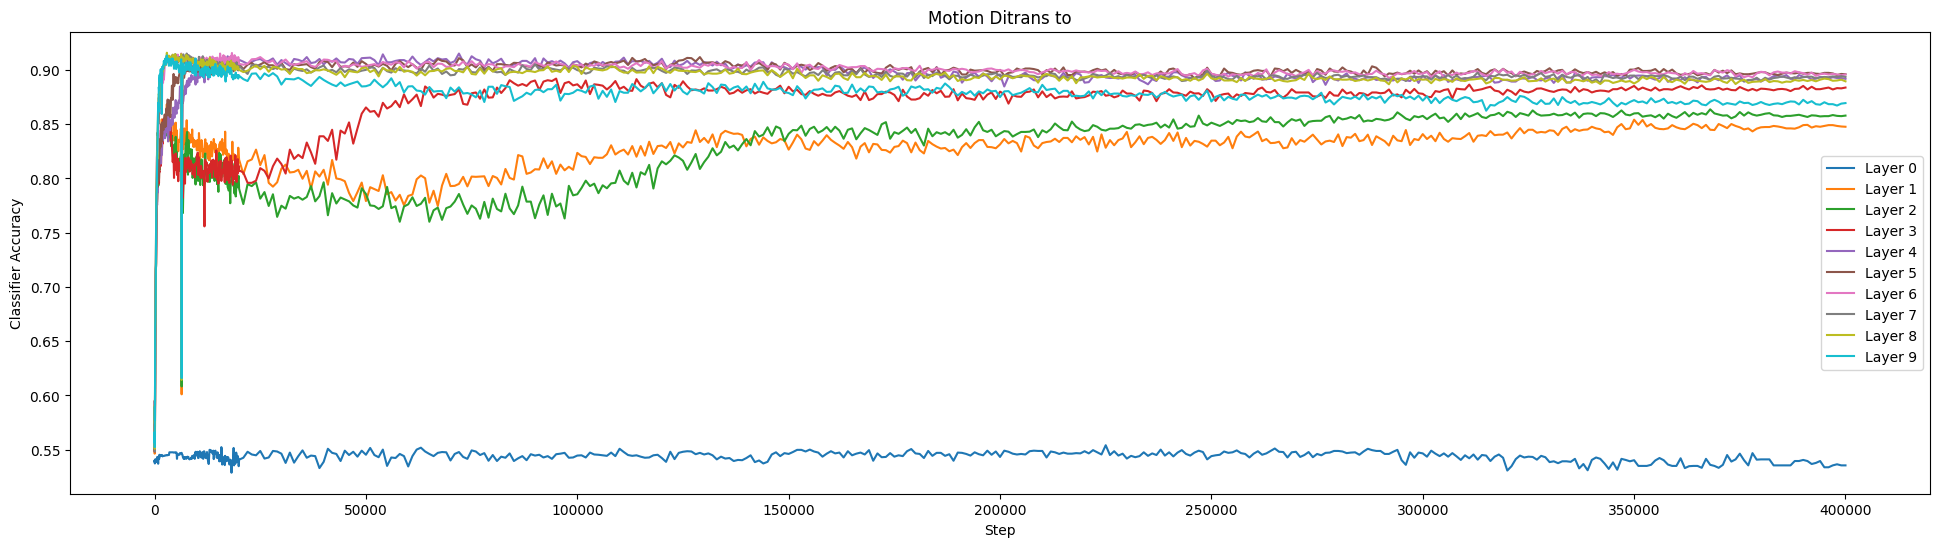

In [5]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_20/battlestar_small.motion.ditrans.target.tsv", "Motion Ditrans to", metric_name="Classifier Accuracy", layers=list(range(10)))

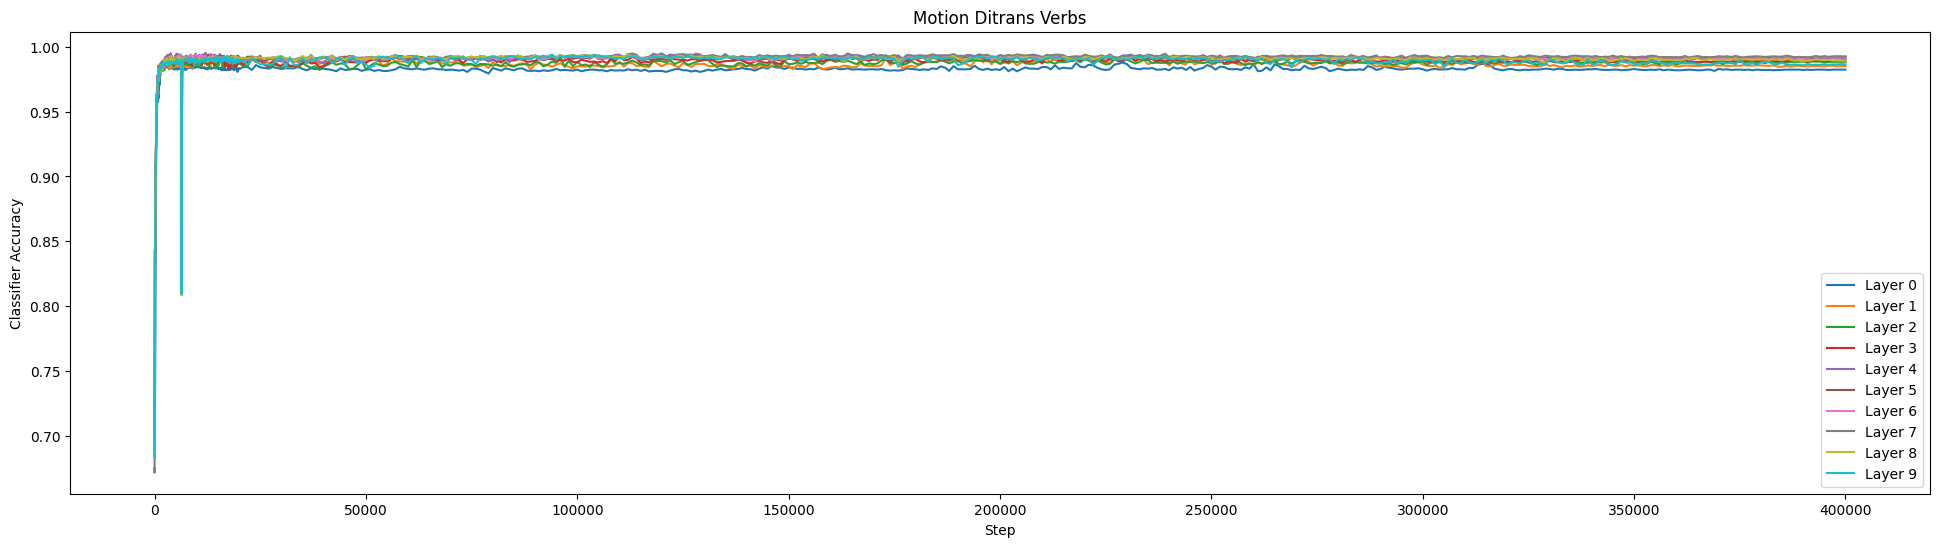

In [6]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_20/battlestar_small.motion.ditrans.dependent.tsv", "Motion Ditrans Verbs", metric_name="Classifier Accuracy", layers=list(range(10)))

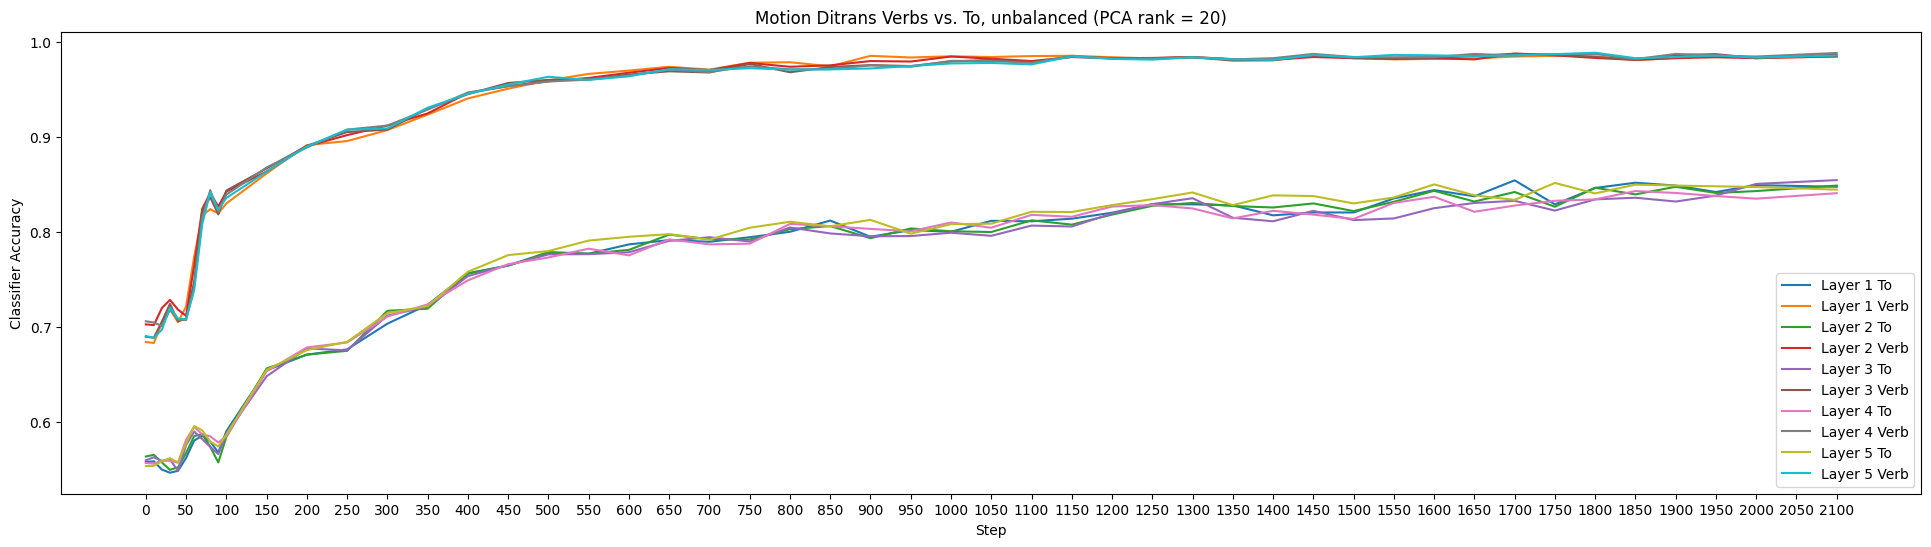

In [25]:
prep_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/battlestar_small.motion.ditrans.target.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/battlestar_small.motion.ditrans.dependent.tsv"

plot_pair_training_curve(prep_results,verb_results, "Motion Ditrans Verbs vs. To, unbalanced (PCA rank = 20)", metric_name="Classifier Accuracy", layers=list(range(1, 6)), x_max=50)

# Motion Ditransitive Balanced

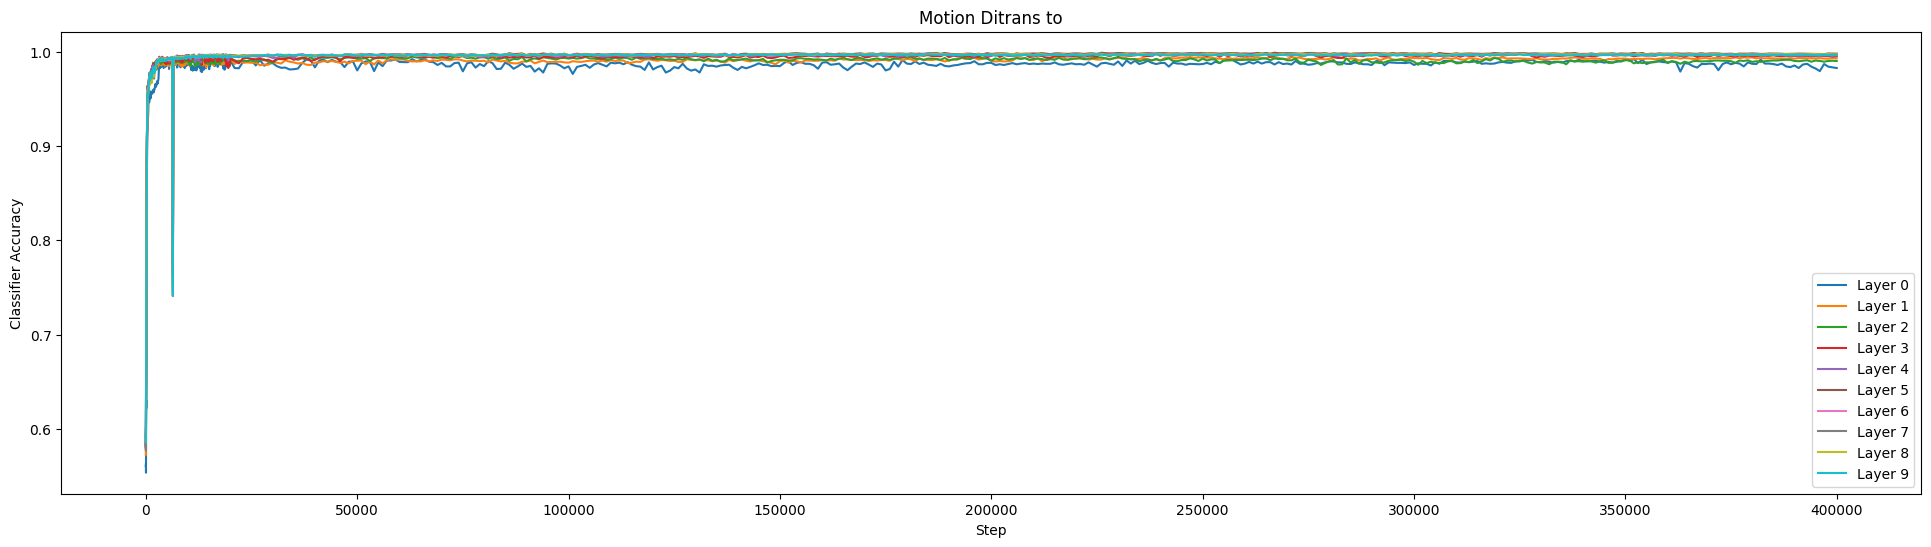

In [6]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_20/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv", "Motion Ditrans to", metric_name="Classifier Accuracy", layers=list(range(10)))

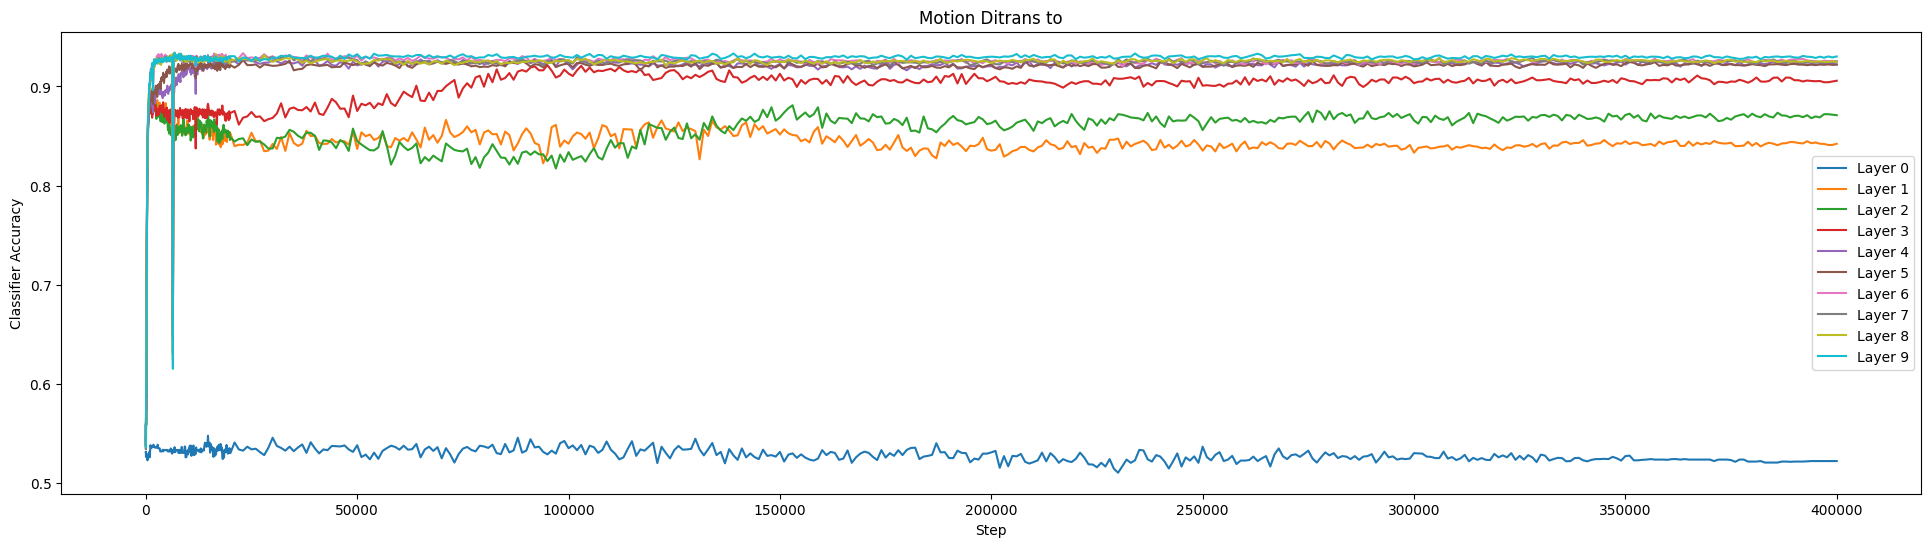

In [11]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/to/ridge_pca_20/battlestar_small.motion_balanced.ditrans_balanced.target.tsv", "Motion Ditrans to", metric_name="Classifier Accuracy", layers=list(range(10)))

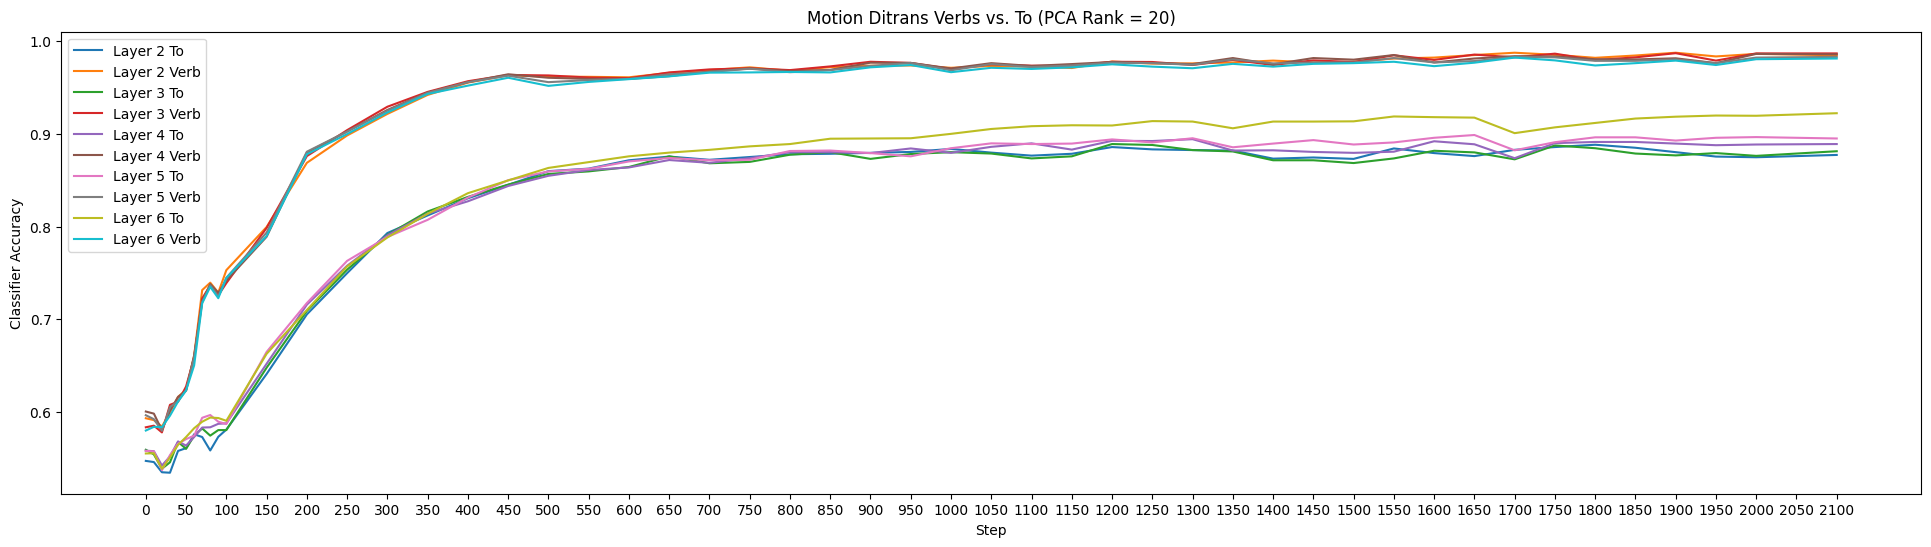

In [31]:
prep_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_20/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"

plot_pair_training_curve(prep_results,verb_results, "Motion Ditrans Verbs vs. To (PCA Rank = 20)", metric_name="Classifier Accuracy", layers=list(range(2, 7)), x_max=50)

# Ablation for motion and ditransitive abstractions

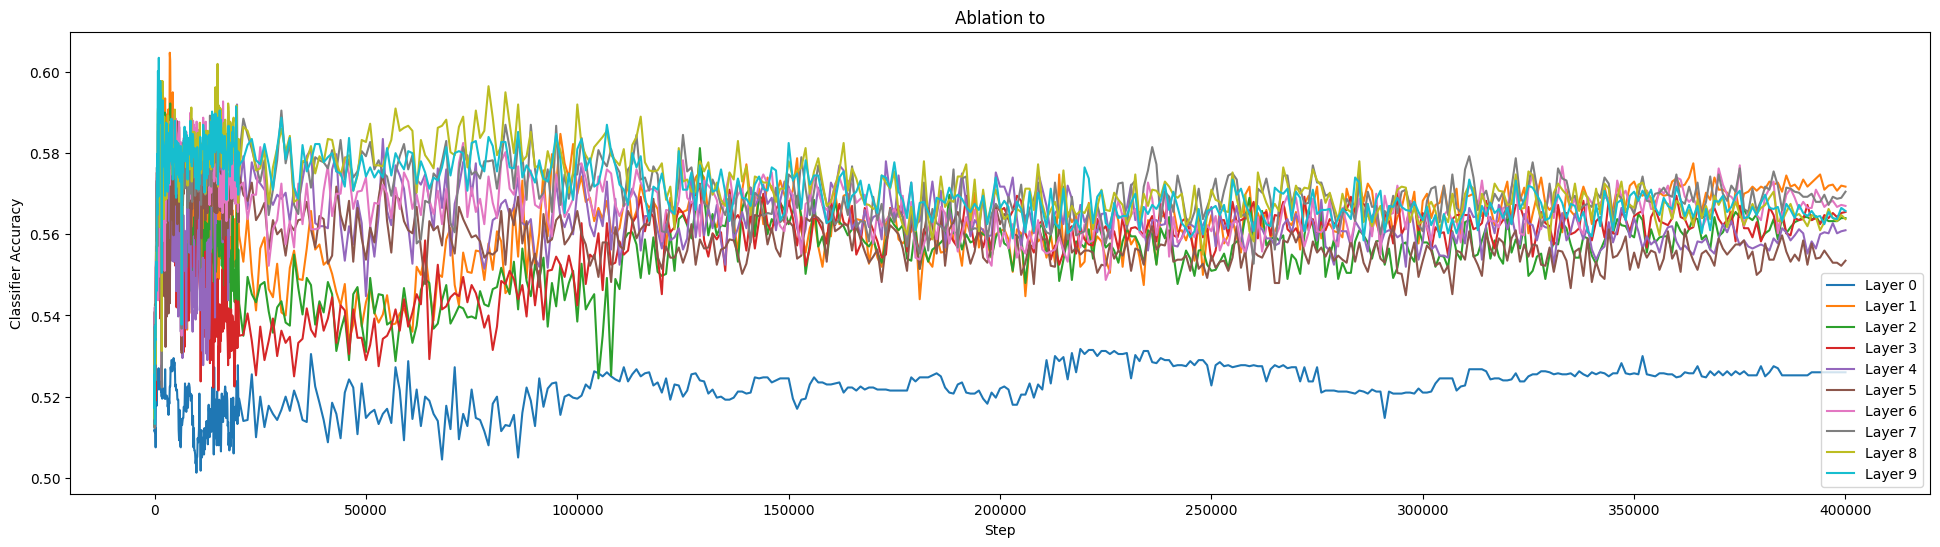

In [60]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/pca_8/battlestar_small.motion_balanced.ditrans_balanced.target.tsv", "Ablation to", metric_name="Classifier Accuracy", layers=list(range(10)))

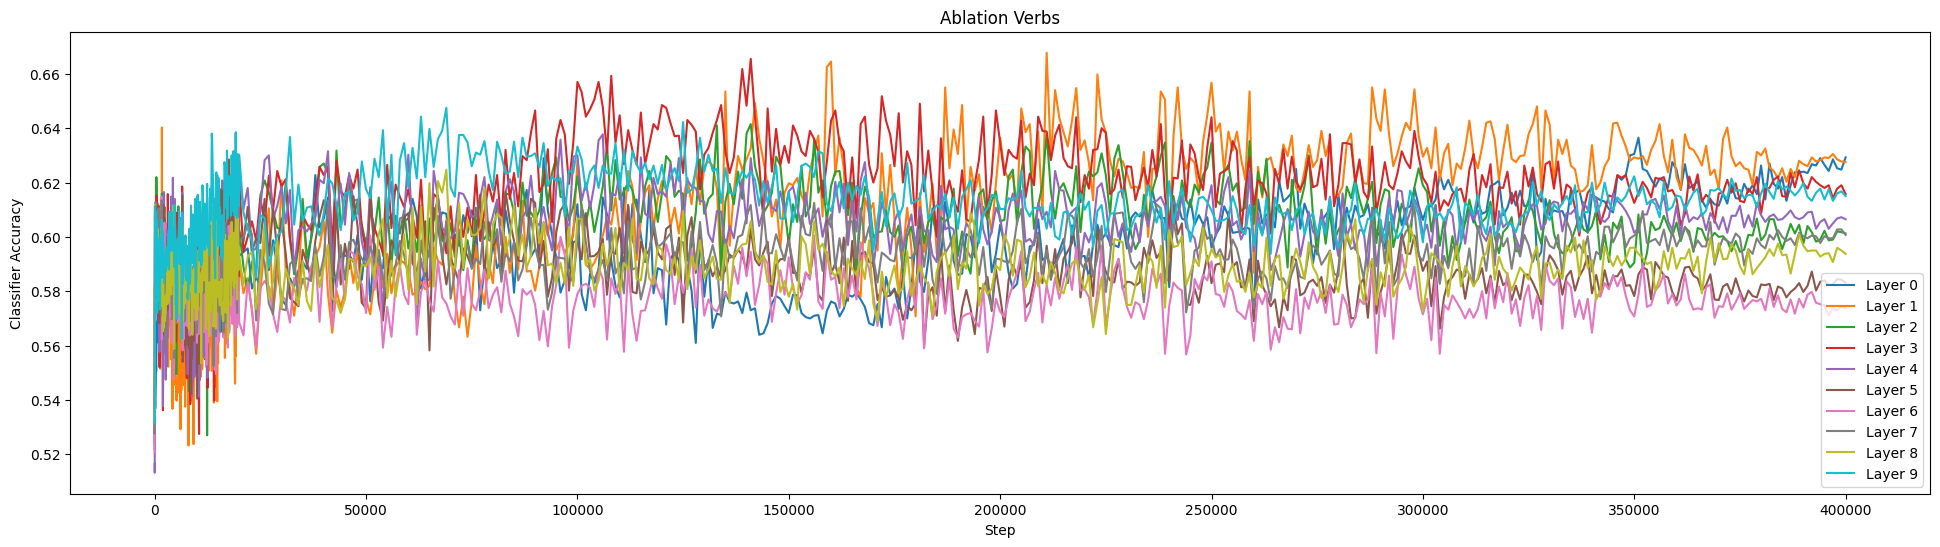

In [61]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/pca_8/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv", "Ablation Verbs", metric_name="Classifier Accuracy", layers=list(range(10)))

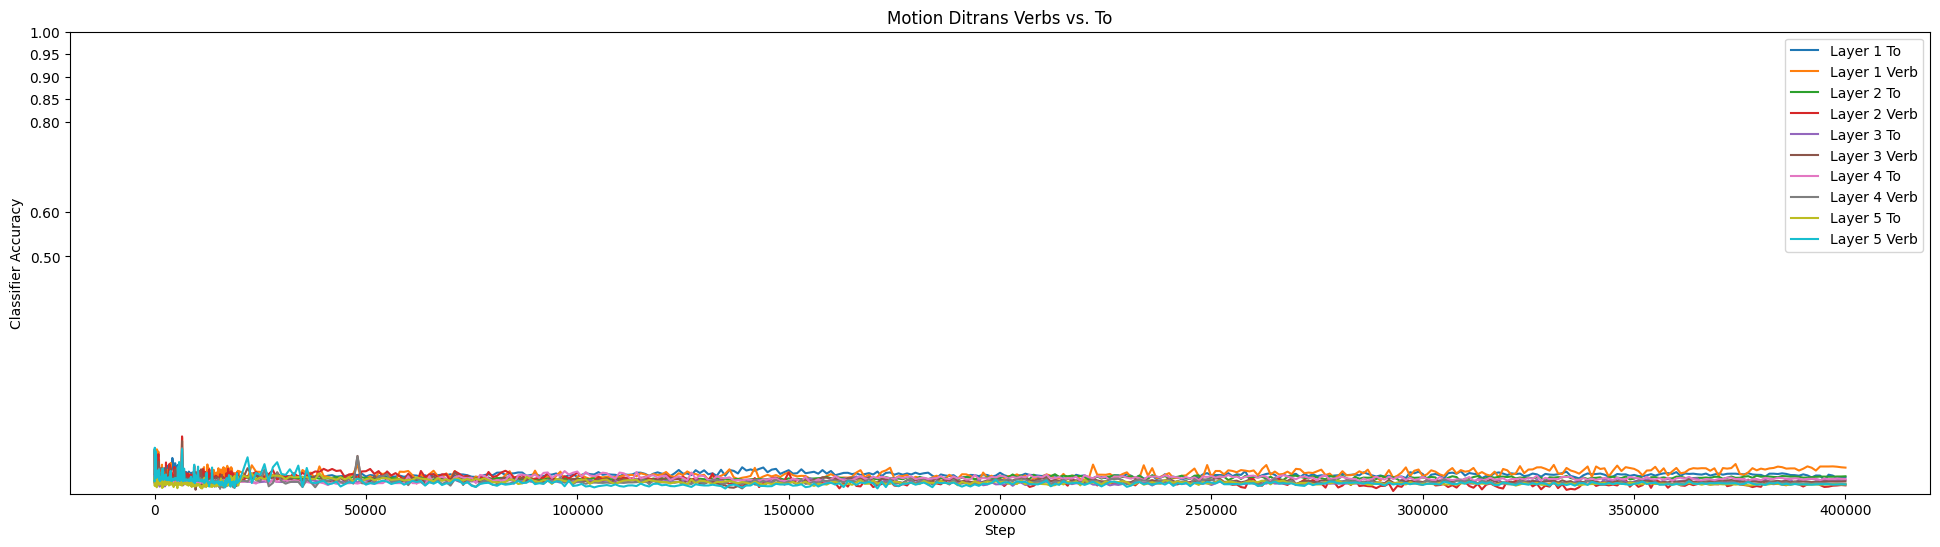

In [47]:
prep_results = "/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/pca_2/battlestar_small.motion_balanced.ditrans_balanced.target.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/ablation/wikitext/to/pca_2/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"

plot_pair_training_curve(prep_results,verb_results, "Motion Ditrans Verbs vs. To", metric_name="Classifier Accuracy", layers=list(range(1, 6)), x_max=None)

# With

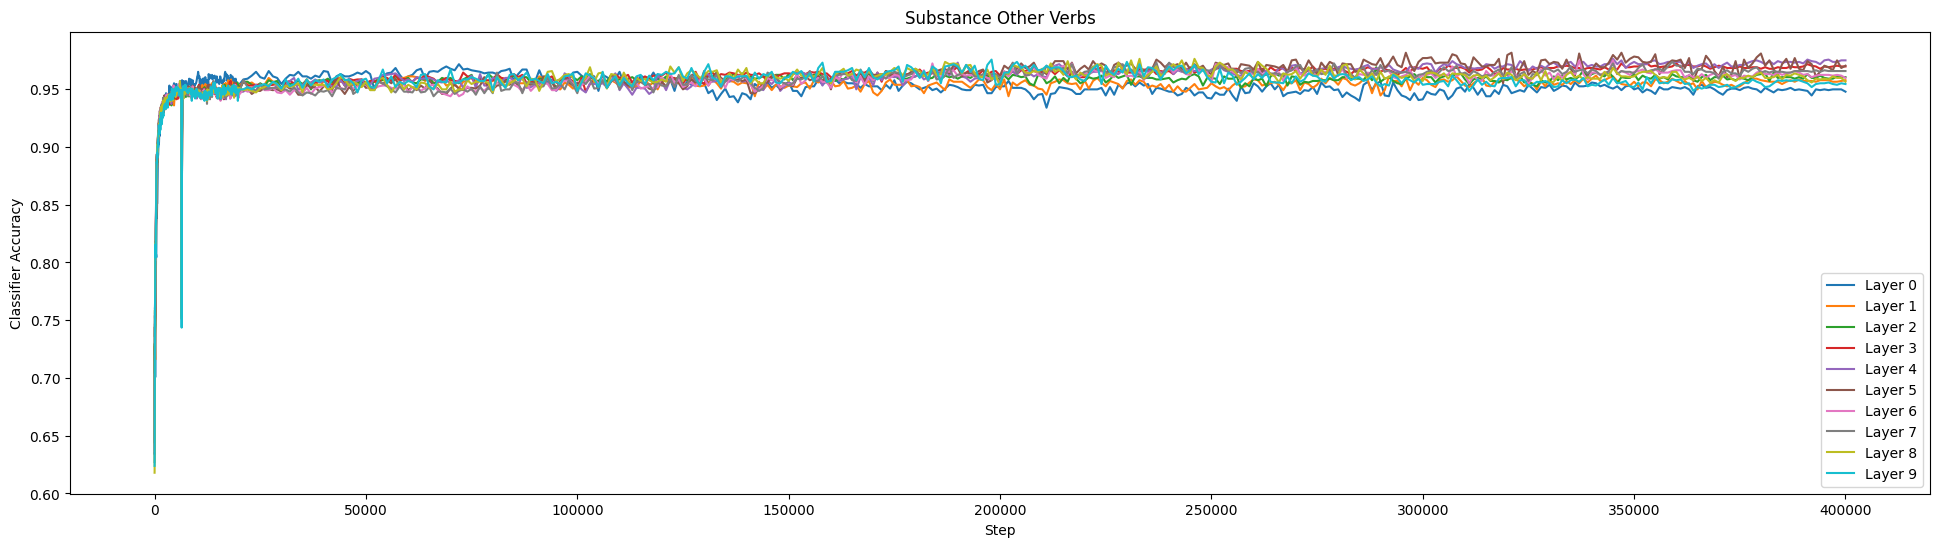

In [5]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/battlestar_small.with.substance.with.adjunct.dependent.tsv", "Substance Other Verbs", metric_name="Classifier Accuracy", layers=list(range(10)))

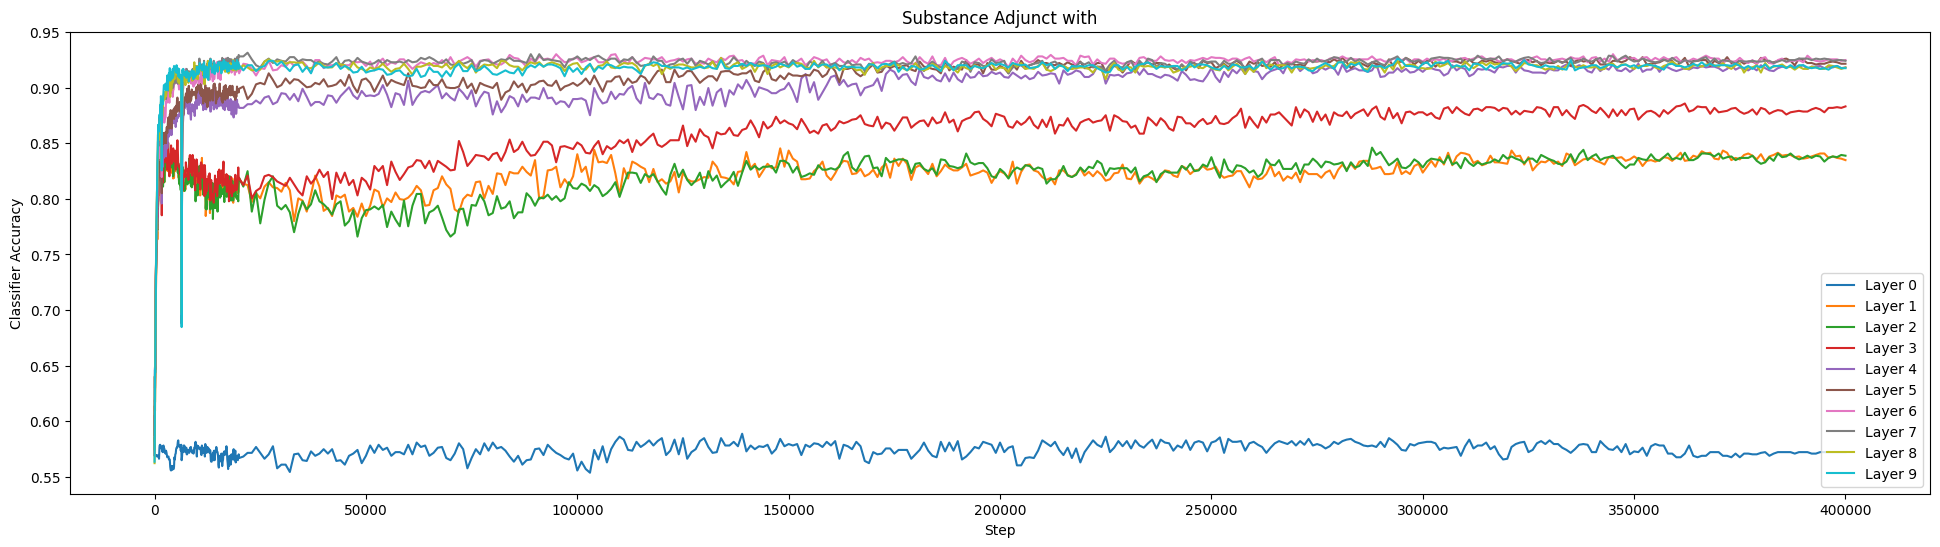

In [6]:
plot_training_curve("/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/battlestar_small.with.substance.with.adjunct.target.tsv", "Substance Adjunct with", metric_name="Classifier Accuracy", layers=list(range(10)))

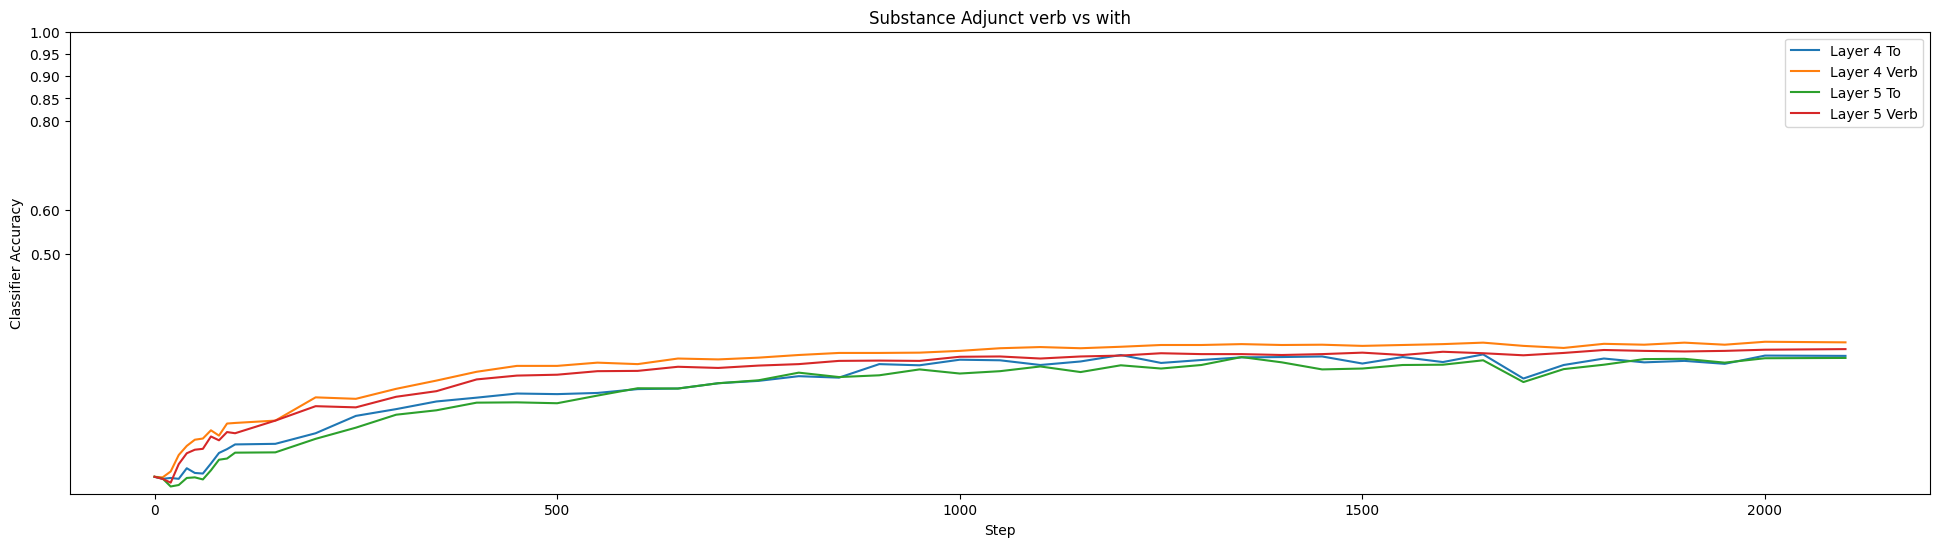

In [42]:
prep_results = "/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/battlestar_small.with.substance.with.adjunct.target.tsv"
verb_results = "/sailhome/jjian/projects/abstraction/results/wikitext/with/pca_20/battlestar_small.with.substance.with.adjunct.dependent.tsv"

plot_pair_training_curve(prep_results,verb_results, "Substance Adjunct verb vs with", metric_name="Classifier Accuracy", layers=list(range(4, 6)), x_max=50)

# Passive Adjunct

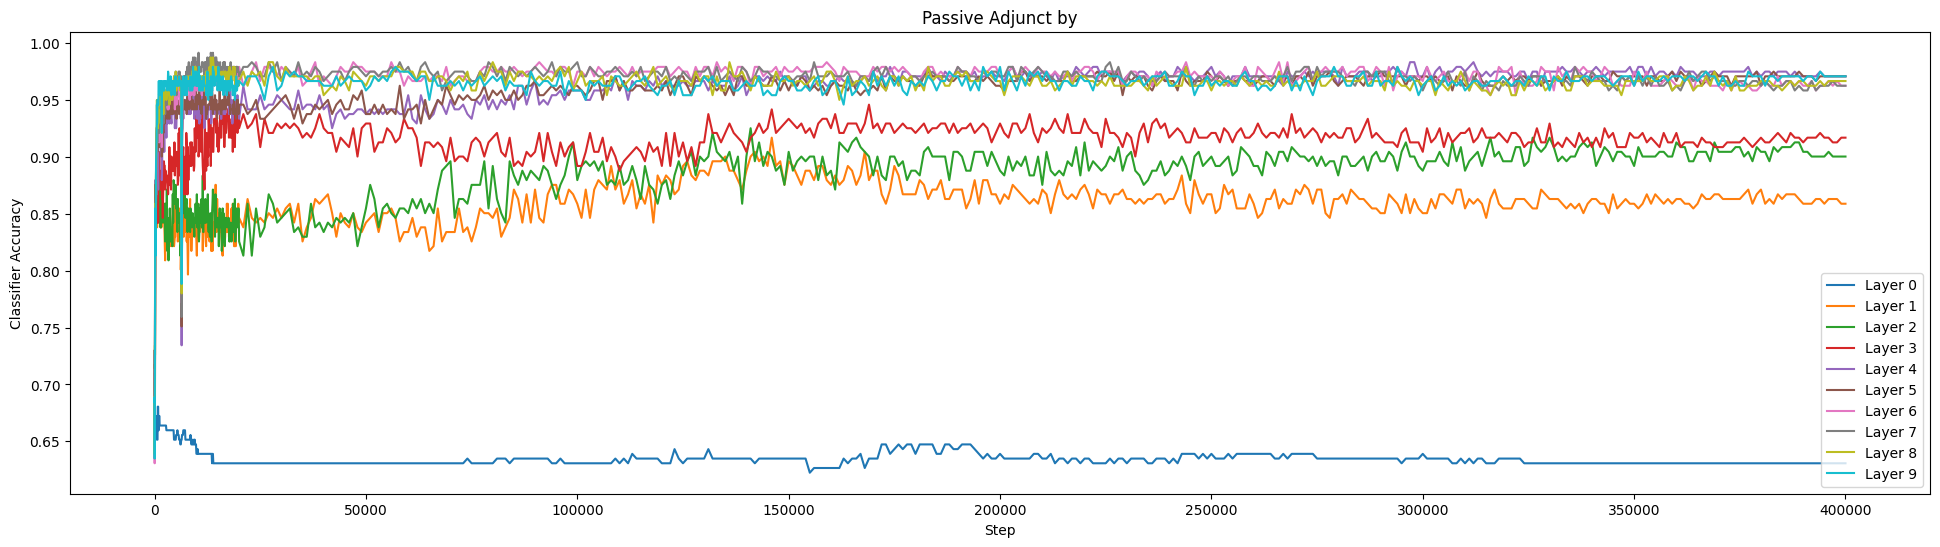

In [17]:
plot_training_curve("/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/en_ewt/by/ridge_pca_20/battlestar_small.by_adjunct.by_passive.target.tsv", "Passive Adjunct by", metric_name="Classifier Accuracy", layers=list(range(10)))

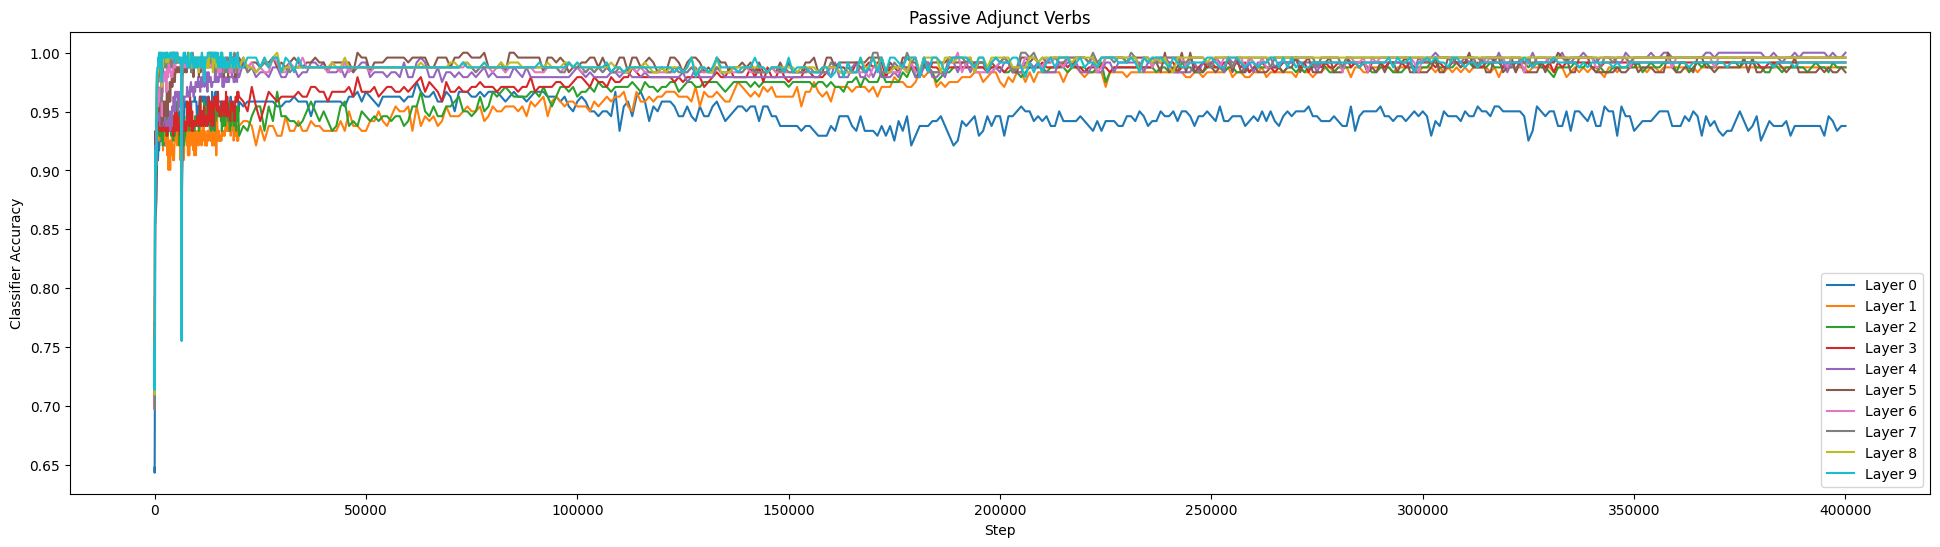

In [18]:
plot_training_curve("/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/en_ewt/by/ridge_pca_20/battlestar_small.by_adjunct.by_passive.dependent.tsv", "Passive Adjunct Verbs", metric_name="Classifier Accuracy", layers=list(range(10)))

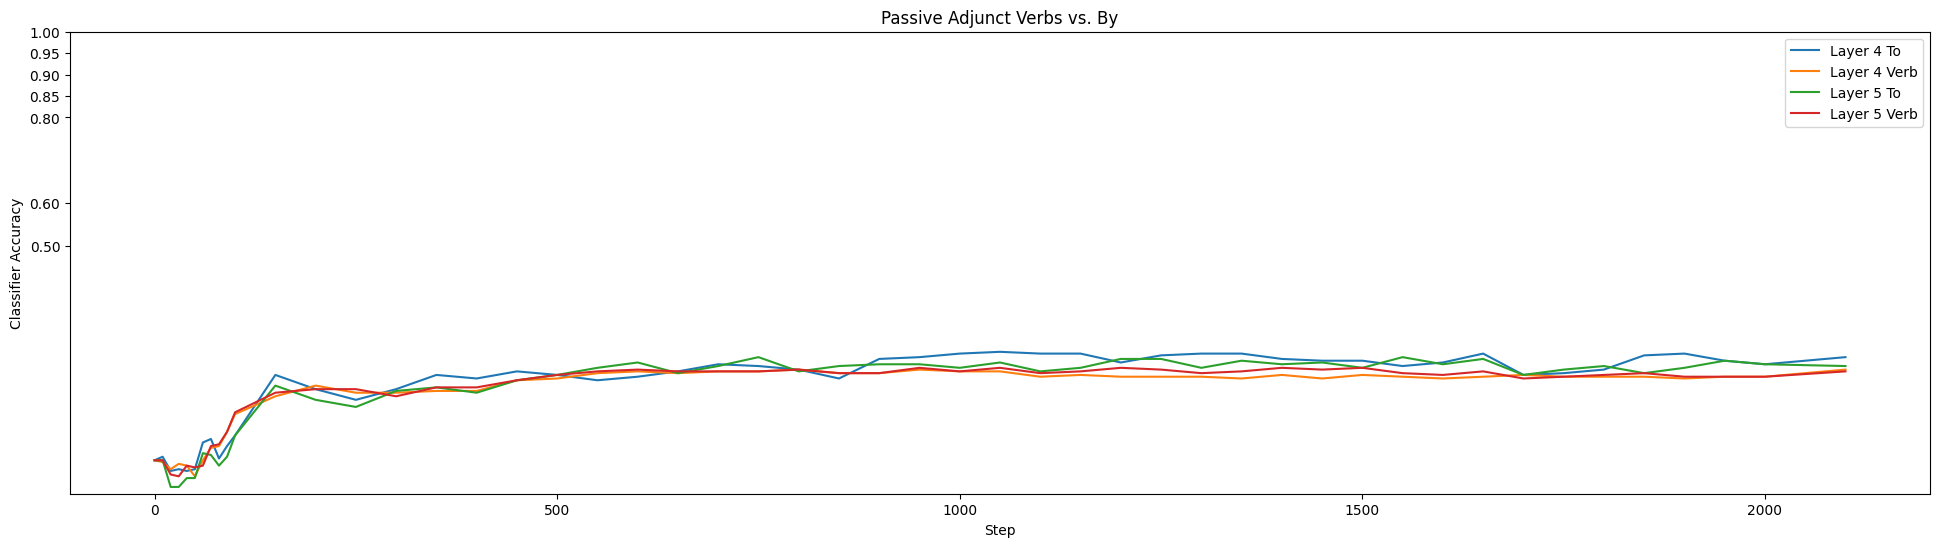

In [9]:
prep_results = "/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/en_ewt/by/ridge_pca_20/battlestar_small.by_adjunct.by_passive.target.tsv"
verb_results = "/afs/cs.stanford.edu/u/jjian/projects/abstraction/results/en_ewt/by/ridge_pca_20/battlestar_small.by_adjunct.by_passive.dependent.tsv"
plot_pair_training_curve(prep_results, verb_results, "Passive Adjunct Verbs vs. By", metric_name="Classifier Accuracy", layers=list(range(4, 6)), x_max=50)